<a href="https://colab.research.google.com/github/smerarawal/IIT-BHU-Proj/blob/main/ui_prmd_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
from scipy.signal import savgol_filter, welch
from scipy.stats import skew, kurtosis
from scipy.ndimage import label as nd_label
from typing import Dict, List, Optional, Tuple

TARGET_LEN   = 150
FPS          = 30
MIN_REP_LEN  = 20
SG_WIN       = 11
SG_POLY      = 3
HESIT_THRESH = 2.0
VALGUS_WARN  = 10.0
ASYMM_WARN   = 15.0

EXERCISE_CONFIGS = {
    'straight_leg_raise': {
        'primary_joints':      ['left_hip', 'right_hip'],
        'bilateral':           False,
        'compensation_proxies': [],
        'ROM_threshold_deg':   30.0,
        'peak_threshold_deg':  130.0,
        'direction':           'flexion',
        'posture':             'supine',
        'scalar_joints':       ['left_hip', 'right_hip', 'left_knee', 'right_knee', None, None],
    },
    'heel_slide': {
        'primary_joints':      ['left_knee', 'right_knee'],
        'bilateral':           False,
        'compensation_proxies': [],
        'ROM_threshold_deg':   60.0,
        'peak_threshold_deg':  100.0,
        'direction':           'flexion',
        'posture':             'supine',
        'scalar_joints':       ['left_knee', 'right_knee', 'left_hip', 'right_hip', None, None],
    },
    'knee_bend_seated': {
        'primary_joints':      ['left_knee', 'right_knee'],
        'bilateral':           True,
        'compensation_proxies': ['trunk_lean', 'hip_knee_coupling'],
        'ROM_threshold_deg':   70.0,
        'peak_threshold_deg':  90.0,
        'direction':           'flexion',
        'posture':             'seated',
        'scalar_joints':       ['left_knee', 'right_knee', 'left_hip', 'right_hip', 'left_ankle', 'right_ankle'],
    },
    'mini_squat': {
        'primary_joints':      ['left_knee', 'right_knee', 'left_hip',  'right_hip'],
        'bilateral':           True,
        'compensation_proxies': ['trunk_lean', 'ankle_dorsiflexion', 'hip_knee_coupling'],
        'ROM_threshold_deg':   70.0,
        'peak_threshold_deg':  100.0,
        'direction':           'flexion',
        'posture':             'standing',
        'scalar_joints':       ['left_knee', 'right_knee', 'left_hip', 'right_hip', 'left_ankle', 'right_ankle'],
    },
    'wall_squat': {
        'primary_joints':      ['left_knee', 'right_knee'],
        'bilateral':           True,
        'compensation_proxies': ['trunk_lean', 'ankle_dorsiflexion', 'hip_knee_coupling'],
        'ROM_threshold_deg':   60.0,
        'peak_threshold_deg':  100.0,
        'direction':           'flexion',
        'posture':             'standing',
        'scalar_joints':       ['left_knee', 'right_knee', 'left_hip', 'right_hip', 'left_ankle', 'right_ankle'],
    },
    'hip_abduction': {
        'primary_joints':      ['left_hip', 'right_hip'],
        'bilateral':           False,
        'compensation_proxies': [],
        'ROM_threshold_deg':   20.0,
        'peak_threshold_deg':  None,
        'direction':           'abduction',
        'posture':             'side_lying',
        'scalar_joints':       ['left_hip', 'right_hip', 'left_knee', 'right_knee', None, None],
    },
    'calf_raise': {
        'primary_joints':      ['left_ankle', 'right_ankle'],
        'bilateral':           True,
        'compensation_proxies': ['hip_knee_coupling'],
        'ROM_threshold_deg':   20.0,
        'peak_threshold_deg':  None,
        'direction':           'extension',
        'posture':             'standing',
        'scalar_joints':       ['left_ankle', 'right_ankle', 'left_knee', 'right_knee', None, None],
    },
    'step_up': {
        'primary_joints':      ['left_knee', 'right_knee', 'left_hip',  'right_hip'],
        'bilateral':           True,
        'compensation_proxies': ['trunk_lean', 'hip_knee_coupling'],
        'ROM_threshold_deg':   60.0,
        'peak_threshold_deg':  100.0,
        'direction':           'flexion',
        'posture':             'standing',
        'scalar_joints':       ['left_knee', 'right_knee', 'left_hip', 'right_hip', 'left_ankle', 'right_ankle'],
    },
}

_DEFAULT_CONFIG = EXERCISE_CONFIGS['mini_squat']

def get_exercise_config(exercise_label: str) -> dict:
    return EXERCISE_CONFIGS.get(exercise_label.lower().replace(' ', '_'), _DEFAULT_CONFIG)

def _smooth(arr: np.ndarray) -> np.ndarray:
    win = min(SG_WIN, len(arr) if len(arr) % 2 == 1 else len(arr) - 1)
    win = max(win, SG_POLY + 2 if (SG_POLY + 2) % 2 == 1 else SG_POLY + 3)
    return savgol_filter(arr, window_length=win, polyorder=SG_POLY)

def _velocity(arr: np.ndarray) -> np.ndarray:
    return np.gradient(arr, 1.0 / FPS)

def _jerk(vel: np.ndarray) -> np.ndarray:
    return np.gradient(np.abs(vel), 1.0 / FPS)

def _normalise_length(arr: np.ndarray, length: int = TARGET_LEN) -> np.ndarray:
    x_old = np.linspace(0, 1, len(arr))
    x_new = np.linspace(0, 1, length)
    return np.interp(x_new, x_old, arr)

def _find_peak_idx(angle: np.ndarray, direction: str) -> int:
    smoothed = _smooth(angle)
    if direction == 'flexion':
        return int(np.argmin(smoothed))
    else:
        return int(np.argmax(smoothed))

def _hesitation_count(vel: np.ndarray, threshold: float = HESIT_THRESH) -> int:
    pausing, _ = nd_label(np.abs(vel) < threshold)
    return max(0, pausing.max())

def _spectral_arc_length(angle: np.ndarray) -> float:
    freqs, psd = welch(angle, fs=FPS, nperseg=min(len(angle), 64))
    psd_norm   = psd / (psd[0] + 1e-8)
    arc        = -np.sum(np.sqrt((freqs[1:] - freqs[:-1])**2 + (psd_norm[1:] - psd_norm[:-1])**2))
    return float(np.clip(1.0 + arc / 50.0, 0.0, 1.0))

def _ec_ratio(angle: np.ndarray, direction: str = 'flexion') -> float:
    peak_idx = _find_peak_idx(angle, direction)
    n = len(angle)
    if peak_idx == 0 or peak_idx == n - 1:
        return 1.0
    return float(peak_idx / (n - peak_idx))

def extract_joint_features(angle: np.ndarray, joint_name: str, direction: str = 'flexion') -> dict:
    if len(angle) < MIN_REP_LEN:
        raise ValueError(f"{joint_name}: rep too short ({len(angle)} frames)")
    s    = _smooth(angle)
    vel  = _velocity(s)
    jerk = _jerk(vel)
    rom       = float(np.max(s) - np.min(s))
    peak_idx  = _find_peak_idx(s, direction)
    if direction == 'flexion':
        peak_ang = float(np.min(s))
    else:
        peak_ang = float(np.max(s))
    start_ang  = float(s[0])
    end_ang    = float(s[-1])
    angle_mean = float(np.mean(s))
    angle_std  = float(np.std(s))
    max_vel       = float(np.max(np.abs(vel)))
    mean_vel      = float(np.mean(np.abs(vel)))
    mean_vel_desc = float(np.mean(np.abs(vel[:peak_idx + 1]))) if peak_idx > 0 else 0.0
    mean_vel_asc  = float(np.mean(np.abs(vel[peak_idx:])))     if peak_idx < len(vel)-1 else 0.0
    vel_skewness  = float(skew(vel))
    vel_kurtosis  = float(kurtosis(vel))
    mean_jerk   = float(np.mean(jerk))
    peak_jerk   = float(np.max(jerk))
    smoothness  = _spectral_arc_length(s)
    hesitations = _hesitation_count(vel)
    ec_ratio    = _ec_ratio(s, direction)
    return {
        f"{joint_name}_ROM":           rom,
        f"{joint_name}_peak_angle":    peak_ang,
        f"{joint_name}_start_angle":   start_ang,
        f"{joint_name}_end_angle":     end_ang,
        f"{joint_name}_angle_mean":    angle_mean,
        f"{joint_name}_angle_std":     angle_std,
        f"{joint_name}_max_velocity":  max_vel,
        f"{joint_name}_mean_velocity": mean_vel,
        f"{joint_name}_mean_vel_desc": mean_vel_desc,
        f"{joint_name}_mean_vel_asc":  mean_vel_asc,
        f"{joint_name}_vel_skewness":  vel_skewness,
        f"{joint_name}_vel_kurtosis":  vel_kurtosis,
        f"{joint_name}_EC_ratio":      ec_ratio,
        f"{joint_name}_mean_jerk":     mean_jerk,
        f"{joint_name}_peak_jerk":     peak_jerk,
        f"{joint_name}_smoothness":    smoothness,
        f"{joint_name}_hesitations":   hesitations,
    }

def extract_wall_squat_features(angles: Dict[str, np.ndarray]) -> dict:
    feats = {}
    for side in ('left', 'right'):
        key = f'{side}_knee'
        if key not in angles:
            feats[f'{side}_hold_duration_fr'] = float('nan')
            feats[f'{side}_hold_stability']   = float('nan')
            continue
        s         = _smooth(angles[key])
        peak_ang  = float(np.min(s))
        in_hold   = np.abs(s - peak_ang) < 5.0
        hold_dur  = int(np.sum(in_hold))
        hold_std  = float(np.std(s[in_hold])) if hold_dur > 0 else float('nan')
        feats[f'{side}_hold_duration_fr'] = hold_dur
        feats[f'{side}_hold_stability']   = hold_std
    return feats

def extract_hip_abduction_features(angles: Dict[str, np.ndarray]) -> dict:
    feats = {}
    for active_side, stable_side in [('left', 'right'), ('right', 'left')]:
        active_key = f'{active_side}_hip'
        stable_key = f'{stable_side}_hip'
        if active_key not in angles or stable_key not in angles:
            feats[f'{active_side}_hip_hike_proxy'] = float('nan')
            continue
        n = min(len(angles[active_key]), len(angles[stable_key]))
        active = _smooth(angles[active_key][:n])
        stable = _smooth(angles[stable_key][:n])
        peak_idx   = _find_peak_idx(active, direction='abduction')
        hike_proxy = float(abs(stable[peak_idx] - stable[0]))
        feats[f'{active_side}_hip_hike_proxy'] = hike_proxy
    return feats

def extract_slr_features(angles: Dict[str, np.ndarray]) -> dict:
    feats = {}
    for side in ('left', 'right'):
        knee_key = f'{side}_knee'
        if knee_key not in angles:
            feats[f'{side}_knee_stability_slr'] = float('nan')
            feats[f'{side}_knee_min_during_slr'] = float('nan')
            continue
        s = _smooth(angles[knee_key])
        feats[f'{side}_knee_stability_slr']  = float(np.std(s))
        feats[f'{side}_knee_min_during_slr'] = float(np.min(s))
    return feats

def extract_calf_raise_features(angles: Dict[str, np.ndarray]) -> dict:
    feats = {}
    for side in ('left', 'right'):
        knee_key = f'{side}_knee'
        if knee_key not in angles:
            feats[f'{side}_knee_drift_calf'] = float('nan')
            continue
        s = _smooth(angles[knee_key])
        feats[f'{side}_knee_drift_calf'] = float(np.max(s) - s[0])
    if 'left_ankle' in angles and 'right_ankle' in angles:
        n  = min(len(angles['left_ankle']), len(angles['right_ankle']))
        la = _smooth(angles['left_ankle'][:n])
        ra = _smooth(angles['right_ankle'][:n])
        l_peak_t = _find_peak_idx(la, 'extension')
        r_peak_t = _find_peak_idx(ra, 'extension')
        feats['calf_peak_timing_lag_fr'] = int(abs(l_peak_t - r_peak_t))
    else:
        feats['calf_peak_timing_lag_fr'] = float('nan')
    return feats

def extract_symmetry_features(left: np.ndarray, right: np.ndarray, joint_name: str) -> dict:
    sl, sr = _smooth(left), _smooth(right)
    rom_l   = float(np.max(sl) - np.min(sl))
    rom_r   = float(np.max(sr) - np.min(sr))
    avg_rom = (rom_l + rom_r) / 2.0 + 1e-6
    sym_index  = float(abs(rom_l - rom_r) / avg_rom * 100.0)
    peak_diff  = float(abs(np.min(sl) - np.min(sr)))
    corr = np.correlate(sl - sl.mean(), sr - sr.mean(), mode='full')
    lag  = int(np.argmax(corr) - (len(sl) - 1))
    vel_l = _velocity(sl)
    vel_r = _velocity(sr)
    vel_sym = float(abs(np.mean(np.abs(vel_l)) - np.mean(np.abs(vel_r))) / (np.mean(np.abs(vel_l)) + np.mean(np.abs(vel_r)) + 1e-6) * 100.0)
    flag_asymm = sym_index > ASYMM_WARN
    return {
        f"{joint_name}_symmetry_index":  sym_index,
        f"{joint_name}_peak_diff":       peak_diff,
        f"{joint_name}_temporal_lag_fr": lag,
        f"{joint_name}_vel_symmetry":    vel_sym,
        f"{joint_name}_flag_asymmetric": int(flag_asymm),
    }

def extract_compensation_features(angles: Dict[str, np.ndarray], active_proxies: List[str], direction: str = 'flexion') -> dict:
    feats = {}
    for side in ('left', 'right'):
        hip_key   = f'{side}_hip'
        knee_key  = f'{side}_knee'
        ankle_key = f'{side}_ankle'
        has_hip   = hip_key   in angles
        has_knee  = knee_key  in angles
        has_ankle = ankle_key in angles

        if 'trunk_lean' in active_proxies and has_hip and has_knee:
            hip  = _smooth(angles[hip_key])
            knee = _smooth(angles[knee_key])
            n    = min(len(hip), len(knee))
            hip, knee = hip[:n], knee[:n]
            peak_idx  = _find_peak_idx(knee, direction)
            trunk_lean = float(abs(hip[peak_idx] - hip[0]))
            feats[f'{side}_trunk_lean_proxy'] = trunk_lean
        else:
            feats[f'{side}_trunk_lean_proxy'] = float('nan')

        if 'ankle_dorsiflexion' in active_proxies and has_ankle:
            ankle     = _smooth(angles[ankle_key])
            ankle_rom = float(np.max(ankle) - np.min(ankle))
            feats[f'{side}_ankle_dorsiflexion'] = ankle_rom
        else:
            feats[f'{side}_ankle_dorsiflexion'] = float('nan')

        if 'hip_knee_coupling' in active_proxies and has_hip and has_knee:
            hip  = _smooth(angles[hip_key])
            knee = _smooth(angles[knee_key])
            n    = min(len(hip), len(knee))
            hip_knee_r = float(np.corrcoef(hip[:n], knee[:n])[0, 1])
            feats[f'{side}_hip_knee_coupling'] = hip_knee_r
        else:
            feats[f'{side}_hip_knee_coupling'] = float('nan')
    return feats

def extract_imu_features(accel: Optional[np.ndarray] = None, gyro:  Optional[np.ndarray] = None) -> dict:
    imu_keys = ['imu_accel_rms', 'imu_accel_peak', 'imu_accel_jerk_rms', 'imu_gyro_rms',  'imu_gyro_peak',  'imu_sway_ap', 'imu_sway_ml',   'imu_step_symm']
    if accel is None or gyro is None:
        return {k: float('nan') for k in imu_keys}
    accel_norm = np.linalg.norm(accel, axis=1)
    gyro_norm  = np.linalg.norm(gyro,  axis=1)
    return {
        'imu_accel_rms':      float(np.sqrt(np.mean(accel_norm**2))),
        'imu_accel_peak':     float(np.max(accel_norm)),
        'imu_accel_jerk_rms': float(np.sqrt(np.mean(np.diff(accel_norm)**2))),
        'imu_gyro_rms':       float(np.sqrt(np.mean(gyro_norm**2))),
        'imu_gyro_peak':      float(np.max(gyro_norm)),
        'imu_sway_ap':        float(np.std(accel[:, 1])),
        'imu_sway_ml':        float(np.std(accel[:, 0])),
        'imu_step_symm':      float(np.correlate(accel[:, 2]-np.mean(accel[:, 2]), accel[:, 2]-np.mean(accel[:, 2]), mode='full')[len(accel)-1:][1]) if len(accel) > 2 else float('nan'),
    }

def compute_clinical_flags(feats: dict, config: dict) -> dict:
    flags    = {}
    rom_thr  = config.get('ROM_threshold_deg', 70.0)
    peak_thr = config.get('peak_threshold_deg', 100.0)
    for side in ('left', 'right'):
        primary = config['primary_joints']
        for joint_key in primary:
            if side not in joint_key: continue
            short_name = joint_key.replace('left_', '').replace('right_', '')
            rom = feats.get(f'{joint_key}_ROM', None)
            if rom is not None: flags[f'{side}_{short_name}_insufficient_ROM'] = int(rom < rom_thr)
            if peak_thr is not None:
                peak = feats.get(f'{joint_key}_peak_angle', None)
                if peak is not None: flags[f'{side}_{short_name}_peak_not_reached'] = int(peak > peak_thr)
        for joint_key in primary:
            if side not in joint_key: continue
            max_vel = feats.get(f'{joint_key}_max_velocity', None)
            if max_vel is not None:
                flags[f'{joint_key}_too_fast'] = int(max_vel > 80.0)
                flags[f'{joint_key}_too_slow'] = int(max_vel < 8.0)
        for joint_key in primary:
            if side not in joint_key: continue
            jerk = feats.get(f'{joint_key}_mean_jerk', None)
            if jerk is not None: flags[f'{joint_key}_high_jerk'] = int(jerk > 12.0)
        trunk = feats.get(f'{side}_trunk_lean_proxy', None)
        if trunk is not None and not np.isnan(trunk): flags[f'{side}_trunk_compensation'] = int(trunk > 20.0)
    if config.get('bilateral', True):
        for joint in ('hip', 'knee', 'ankle'):
            sym = feats.get(f'{joint}_symmetry_index', None)
            if sym is not None: flags[f'{joint}_asymmetric'] = int(sym > ASYMM_WARN)
    return flags

def build_model_inputs(angles: Dict[str, np.ndarray], config: dict, valgus_angle: float = 0.0, target_len: int = TARGET_LEN) -> Tuple[np.ndarray, np.ndarray]:
    joint_order = ['left_hip', 'left_knee', 'left_ankle', 'right_hip', 'right_knee', 'right_ankle']
    ts_channels = []
    for j in joint_order:
        arr  = angles.get(j, np.zeros(target_len))
        norm = _normalise_length(_smooth(arr), target_len) / 180.0
        ts_channels.append(norm)
    ts_input = np.stack(ts_channels, axis=1).astype(np.float32)
    primary_key = config['primary_joints'][0]
    raw = angles.get(primary_key, np.zeros(10))
    s = _smooth(raw)
    v = _velocity(s)
    j = _jerk(v)
    direction = config.get('direction', 'flexion')
    rom     = float(np.max(s) - np.min(s))
    peak    = float(np.min(s)) if direction == 'flexion' else float(np.max(s))
    max_vel = float(np.max(np.abs(v)))
    mean_jk = float(np.mean(j))
    sym = 0.0
    opp_key = primary_key.replace('left_', 'right_').replace('right_', 'left_')
    if opp_key in angles:
        opp_s    = _smooth(angles[opp_key])
        opp_rom  = float(np.max(opp_s) - np.min(opp_s))
        sym      = abs(rom - opp_rom) / ((rom + opp_rom) / 2.0 + 1e-6) * 100.0
    scalar_input = np.array([rom / 180.0, peak / 180.0, max_vel / 200.0, mean_jk / 50.0, sym / 100.0, valgus_angle / 45.0], dtype=np.float32)
    return ts_input, scalar_input

def extract_all_features(angles: Dict[str, np.ndarray], exercise_label: str = 'mini_squat', imu_accel: Optional[np.ndarray] = None, imu_gyro:  Optional[np.ndarray] = None, valgus_angle: float = 0.0, rep_id: str = '') -> dict:
    config = get_exercise_config(exercise_label)
    direction = config.get('direction', 'flexion')
    feats = {'rep_id': rep_id, 'exercise': exercise_label, 'n_frames_raw': max((len(v) for v in angles.values()), default=0), 'valgus_angle': valgus_angle}
    all_joints = ['left_hip', 'left_knee', 'left_ankle', 'right_hip', 'right_knee', 'right_ankle']
    _dummy_keys = ['ROM', 'peak_angle', 'start_angle', 'end_angle', 'angle_mean', 'angle_std', 'max_velocity', 'mean_velocity', 'mean_vel_desc', 'mean_vel_asc', 'vel_skewness', 'vel_kurtosis', 'EC_ratio', 'mean_jerk', 'peak_jerk', 'smoothness', 'hesitations']
    for key in all_joints:
        if key in angles and len(angles[key]) >= MIN_REP_LEN:
            feats.update(extract_joint_features(angles[key], key, direction))
        else:
            feats.update({f'{key}_{k}': float('nan') for k in _dummy_keys})
    if config.get('bilateral', True):
        for joint in ('hip', 'knee', 'ankle'):
            lk, rk = f'left_{joint}', f'right_{joint}'
            if lk in angles and rk in angles:
                n = min(len(angles[lk]), len(angles[rk]))
                feats.update(extract_symmetry_features(angles[lk][:n], angles[rk][:n], joint))
    feats.update(extract_compensation_features(angles, config['compensation_proxies'], direction))
    if exercise_label == 'wall_squat': feats.update(extract_wall_squat_features(angles))
    elif exercise_label == 'hip_abduction': feats.update(extract_hip_abduction_features(angles))
    elif exercise_label == 'straight_leg_raise': feats.update(extract_slr_features(angles))
    elif exercise_label == 'calf_raise': feats.update(extract_calf_raise_features(angles))
    feats.update(extract_imu_features(imu_accel, imu_gyro))
    feats['clinical_flags'] = compute_clinical_flags(feats, config)
    ts_input, scalar_input = build_model_inputs(angles, config, valgus_angle=valgus_angle)
    feats['ts_input']     = ts_input
    feats['scalar_input'] = scalar_input
    return feats

In [5]:
import os
import pandas as pd
import numpy as np

def calculate_3d_angle(p_above, p_center, p_below):
    vec_A = p_above - p_center
    vec_B = p_below - p_center
    dot_prod = np.sum(vec_A * vec_B, axis=1)
    norm_A = np.linalg.norm(vec_A, axis=1)
    norm_B = np.linalg.norm(vec_B, axis=1)
    cos_angle = dot_prod / (norm_A * norm_B + 1e-8)
    return np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))

def get_joint_coords(data, joint_idx):
    return data[:, joint_idx * 3 : joint_idx * 3 + 3]

def convert_positions_to_angles(data_matrix):
    # UI-PRMD Kinect joint tracking positions
    waist = get_joint_coords(data_matrix, 0)
    l_hip = get_joint_coords(data_matrix, 14)
    l_knee = get_joint_coords(data_matrix, 15)
    l_ankle = get_joint_coords(data_matrix, 16)
    l_toe = get_joint_coords(data_matrix, 17)
    r_hip = get_joint_coords(data_matrix, 18)
    r_knee = get_joint_coords(data_matrix, 19)
    r_ankle = get_joint_coords(data_matrix, 20)
    r_toe = get_joint_coords(data_matrix, 21)

    return {
        'left_hip':    calculate_3d_angle(waist, l_hip, l_knee),
        'left_knee':   calculate_3d_angle(l_hip, l_knee, l_ankle),
        'left_ankle':  calculate_3d_angle(l_knee, l_ankle, l_toe),
        'right_hip':   calculate_3d_angle(waist, r_hip, r_knee),
        'right_knee':  calculate_3d_angle(r_hip, r_knee, r_ankle),
        'right_ankle': calculate_3d_angle(r_knee, r_ankle, r_toe)
    }

def parse_filename_metadata(filename):
    parts = filename.split('_')
    mov_type = parts[0]
    subject_id = parts[1]

    mapping = {
        'm01': 'mini_squat',
        'm02': 'step_up',
        'm03': 'step_up',
        'm04': 'step_up',
        'm05': 'knee_bend_seated',
        'm06': 'straight_leg_raise'
    }
    return mapping.get(mov_type, 'mini_squat'), subject_id

def process_entire_drive_dataset():
    # Base target folder in Drive
    base_dir = "/content/drive/MyDrive/ui-prmd"

    all_dataset_rows = []
    correct_count = 0
    incorrect_count = 0

    print("Crawling folders recursively to locate raw target text files...")

    # os.walk traverses everything dynamically to bypass path typos
    for root, dirs, files in os.walk(base_dir):
        # Focus strictly on files deep inside a kinect position tracking folder
        if "kinect" in root.lower() and "pos" in root.lower():
            for filename in files:
                if filename.endswith('.txt') and not filename.startswith('.'):
                    filepath = os.path.join(root, filename)

                    # Sort files based on path parameters to assign labels
                    if "incorrect" in filepath.lower() or "segented" in filepath.lower():
                        label = 0
                        incorrect_count += 1
                    else:
                        label = 1
                        correct_count += 1

                    try:
                        # Parse files safely regardless of comma/space delimiters
                        raw_matrix = pd.read_csv(filepath, header=None, sep=None, engine='python').to_numpy()
                        angles_dict = convert_positions_to_angles(raw_matrix)
                        exercise_label, subject_id = parse_filename_metadata(filename)

                        # Generate features via your engineering code from Cell 2
                        feats = extract_all_features(angles_dict, exercise_label=exercise_label, rep_id=filename)
                        feats['target_label'] = label
                        feats['subject_id'] = subject_id

                        all_dataset_rows.append(feats)
                    except Exception as e:
                        print(f"Skipping corrupt record {filename}: {str(e)}")

    print(f"\nDiscovered and evaluated {correct_count} correct and {incorrect_count} incorrect execution tracking records.")
    return pd.DataFrame(all_dataset_rows)

# Execute the search configuration pipeline
df_model_ready = process_entire_drive_dataset()
print(f"Compiled dataframe dimensions: {df_model_ready.shape}")

Crawling folders recursively to locate raw target text files...

Discovered and evaluated 1000 correct and 476 incorrect execution tracking records.
Compiled dataframe dimensions: (1476, 144)


In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.impute import SimpleImputer

# 1. Separate target labels and groups
y = df_model_ready['target_label'].to_numpy()
groups = df_model_ready['subject_id'].to_numpy()  # Forces subjects to stay intact

# 2. Extract Deep Learning matrices if you need them for PyTorch later
X_time_series = np.stack(df_model_ready['ts_input'].to_numpy())      # Shape: (1476, 150, 6)
X_nn_scalars  = np.stack(df_model_ready['scalar_input'].to_numpy())   # Shape: (1476, 6)

# 3. Isolate tabular features for traditional ML (XGBoost / Random Forest)
# We drop metadata and embedded arrays to get a clean, flat feature matrix
exclude_cols = ['rep_id', 'exercise', 'clinical_flags', 'ts_input', 'scalar_input', 'subject_id', 'target_label']
feature_cols = [col for col in df_model_ready.columns if col not in exclude_cols]

X_tabular = df_model_ready[feature_cols].to_numpy()

print(f"Tabular Feature Matrix Shape: {X_tabular.shape}")
print(f"Unique Subjects Found: {np.unique(groups)}")

# 4. Initialize Group-Safe Cross-Validation
logo = LeaveOneGroupOut()
fold_accuracies = []

print("\nStarting Leave-One-Subject-Out Cross-Validation...")

for fold, (train_idx, test_idx) in enumerate(logo.split(X_tabular, y, groups=groups)):
    # Split the data based on subject boundaries
    X_train, X_test = X_tabular[train_idx], X_tabular[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Handle missing values (e.g., tracking channels that are naturally NaN for certain postures)
    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    # Train the baseline head
    clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
    clf.fit(X_train_imp, y_train)

    # Evaluate performance
    preds = clf.predict(X_test_imp)
    acc = accuracy_score(y_test, preds)
    fold_accuracies.append(acc)

    print(f"Fold {fold+1} - Left out subject {groups[test_idx][0]}: Accuracy = {acc:.4f}")

print(f"\nFinal Leak-Free Mean Accuracy: {np.mean(fold_accuracies):.4f}")

Tabular Feature Matrix Shape: (1476, 137)
Unique Subjects Found: ['s01' 's02' 's03' 's04' 's05' 's06' 's07' 's08' 's09' 's10']

Starting Leave-One-Subject-Out Cross-Validation...


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [125 126 127 128 129 130 131 132]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [125 126 127 128 129 130 131 132]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Fold 1 - Left out subject s01: Accuracy = 0.7800


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [125 126 127 128 129 130 131 132]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [125 126 127 128 129 130 131 132]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Fold 2 - Left out subject s02: Accuracy = 0.6733


...

Fold 8 - Left out subject s08: Accuracy = 0.7740


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [125 126 127 128 129 130 131 132]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [125 126 127 128 129 130 131 132]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Fold 9 - Left out subject s09: Accuracy = 0.7286


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [125 126 127 128 129 130 131 132]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [125 126 127 128 129 130 131 132]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Fold 10 - Left out subject s10: Accuracy = 0.7643

Final Leak-Free Mean Accuracy: 0.7400


In [8]:
df_model_ready.head()

,rep_id,exercise,n_frames_raw,valgus_angle,left_hip_ROM,left_hip_peak_angle,left_hip_start_angle,left_hip_end_angle,left_hip_angle_mean,left_hip_angle_std,...,imu_step_symm,clinical_flags,ts_input,scalar_input,target_label,subject_id,left_knee_stability_slr,left_knee_min_during_slr,right_knee_stability_slr,right_knee_min_during_slr
0,m01_s05_e01_positions.txt,mini_squat,103,0.0,11.239598,92.539682,103.717200,103.767811,98.020774,4.220736,...,NaN,"{'left_knee_insufficient_ROM': 0, 'left_knee_p...","[[0.5762067, -0.0028397914, 0.9759293, 0.58134...","[0.99843687, -0.0028397914, 6.008738, -4.40860...",1,s05,NaN,NaN,NaN,NaN
1,m01_s03_e02_positions.txt,mini_squat,83,0.0,10.722111,93.033294,103.729458,103.509704,98.379470,3.965971,...,NaN,"{'left_knee_insufficient_ROM': 1, 'left_knee_p...","[[0.57627475, 0.9284944, 0.0788955, 0.57807845...","[0.253259, 0.7544021, 2.1875613, 0.06694335, 0...",1,s03,NaN,NaN,NaN,NaN
2,m01_s07_e07_positions.txt,mini_squat,113,0.0,8.085522,94.833233,102.794757,102.908705,99.599223,2.920470,...,NaN,"{'left_knee_insufficient_ROM': 0, 'left_knee_p...","[[0.571082, 0.93337244, 0.08467665, 0.5723784,...","[1.0325403, -0.017527103, 4.8152795, 0.0031822...",1,s07,NaN,NaN,NaN,NaN
3,m01_s07_e08_positions.txt,mini_squat,114,0.0,7.893559,95.036431,102.915440,102.856846,99.658752,2.890685,...,NaN,"{'left_knee_insufficient_ROM': 0, 'left_knee_p...","[[0.5717524, 0.9338045, 0.081122145, 0.5722691...","[1.0304255, -0.016330695, 4.7989497, -0.002738...",1,s07,NaN,NaN,NaN,NaN
4,m01_s03_e05_positions.txt,mini_squat,82,0.0,11.169933,92.812381,103.877448,103.856839,98.816655,4.205319,...,NaN,"{'left_knee_insufficient_ROM': 0, 'left_knee_p...","[[0.57709694, 0.9281662, 0.081847645, 0.579644...","[0.59454715, 0.41380516, 4.930287, -0.00168020...",1,s03,NaN,NaN,NaN,NaN


In [9]:
# View rows where the exercise is specifically straight leg raise
df_model_ready[df_model_ready['exercise'] == 'straight_leg_raise'][['exercise', 'left_knee_stability_slr', 'left_knee_min_during_slr']].head()

,exercise,left_knee_stability_slr,left_knee_min_during_slr
414,straight_leg_raise,0.928378,163.721913
418,straight_leg_raise,9.196650,-2.789035
419,straight_leg_raise,0.951974,10.238233
421,straight_leg_raise,73.386351,-1.292493
430,straight_leg_raise,0.711974,164.368699


In [10]:
import pandas as pd

# Load the binary file from your drive
df = pd.read_pickle("/content/drive/MyDrive/ui-prmd/extracted_features.pkl")

# Drop the complex deep learning matrix arrays so the spreadsheet stays clean
df_readable = df.drop(columns=['ts_input', 'scalar_input'])

# Save it as a standard CSV file right next to your pkl file
csv_save_path = "/content/drive/MyDrive/ui-prmd/readable_features.csv"
df_readable.to_csv(csv_save_path, index=False)

print(f"Success! Human-readable file saved to: {csv_save_path}")

Success! Human-readable file saved to: /content/drive/MyDrive/ui-prmd/readable_features.csv


In [33]:
import os
import pandas as pd
import numpy as np

def parse_filename_metadata(filename):
    """Parses exercise labels and subject IDs from UI-PRMD filenames."""
    parts = filename.split('_')
    mov_type = parts[0]
    subject_id = parts[1]
    mapping = {
        'm01': 'mini_squat', 'm02': 'step_up', 'm03': 'step_up',
        'm04': 'step_up', 'm05': 'knee_bend_seated', 'm06': 'straight_leg_raise'
    }
    return mapping.get(mov_type, 'mini_squat'), subject_id

def get_joint_coords(data, joint_idx):
    """Extracts X, Y, Z vector components for a given joint index column group."""
    return data[:, joint_idx * 3 : joint_idx * 3 + 3]

def calculate_geometric_valgus(pos_matrix):
    """
    Computes true clinical knee valgus by measuring the frontal plane (X, Y)
    angular deviation of the knee from the absolute hip-to-ankle tracking line.
    """
    # 1. Accumulate parent-relative coordinates to reconstruct absolute space
    abs_waist   = get_joint_coords(pos_matrix, 0)

    # Left Lower Limb absolute joint positions
    abs_l_hip   = abs_waist + get_joint_coords(pos_matrix, 14)
    abs_l_knee  = abs_l_hip + get_joint_coords(pos_matrix, 15)
    abs_l_ankle = abs_l_knee + get_joint_coords(pos_matrix, 16)

    # Right Lower Limb absolute joint positions
    abs_r_hip   = abs_waist + get_joint_coords(pos_matrix, 18)
    abs_r_knee  = abs_r_hip + get_joint_coords(pos_matrix, 19)
    abs_r_ankle = abs_r_knee + get_joint_coords(pos_matrix, 20)

    def compute_side_valgus(hip_2d, knee_2d, ankle_2d):
        # Isolate the 2D frontal projection plane (X and Y coordinates)
        v_hk = knee_2d[:, :2] - hip_2d[:, :2]
        v_ha = ankle_2d[:, :2] - hip_2d[:, :2]

        dot_prod = np.sum(v_hk * v_ha, axis=1)
        norm_hk = np.linalg.norm(v_hk, axis=1)
        norm_ha = np.linalg.norm(v_ha, axis=1)

        cos_ang = dot_prod / (norm_hk * norm_ha + 1e-8)
        angles = np.degrees(np.arccos(np.clip(cos_ang, -1.0, 1.0)))

        # Calculate dynamic change relative to frame 0 to eliminate initial stance offsets
        dev = np.abs(angles - angles[0])
        return np.max(dev)

    valgus_l = compute_side_valgus(abs_l_hip, abs_l_knee, abs_l_ankle)
    valgus_r = compute_side_valgus(abs_r_hip, abs_r_knee, abs_r_ankle)

    return float(max(valgus_l, valgus_r))

def process_entire_drive_dataset():
    base_dir = "/content/drive/MyDrive/ui-prmd"
    all_dataset_rows = []

    print("Synchronizing and reading matching Angles and Positions data streams...")

    for root, dirs, files in os.walk(base_dir):
        if "kinect" in root.lower() and "angles" in root.lower():
            for filename in files:
                if filename.endswith('.txt') and not filename.startswith('.'):
                    filepath_angles = os.path.join(root, filename)

                    # Dynamically pinpoint the corresponding file inside the positions directory
                    filepath_positions = filepath_angles.replace("/angles/", "/positions/").replace("_angles.txt", "_positions.txt")
                    if not os.path.exists(filepath_positions):
                        filepath_positions = filepath_angles.replace("/Angles/", "/Positions/").replace("angles", "positions")

                    if not os.path.exists(filepath_positions):
                        continue # Skip if matching file is missing

                    label = 0 if ("incorrect" in filepath_angles.lower() or "segented" in filepath_angles.lower()) else 1

                    try:
                        # Stream 1: Ingest pre-calculated flexion angles
                        raw_angles = pd.read_csv(filepath_angles, header=None, sep=None, engine='python').to_numpy()

                        # Stream 2: Ingest matching coordinates matrix
                        raw_positions = pd.read_csv(filepath_positions, header=None, sep=None, engine='python').to_numpy()

                        # Calibrate flexion streams
                        angles_dict = {
                            'left_hip':    180.0 - np.abs(raw_angles[:, 14 * 3 + 1]),
                            'left_knee':   180.0 - np.abs(raw_angles[:, 15 * 3 + 1]),
                            'left_ankle':  180.0 - np.abs(raw_angles[:, 16 * 3 + 1]),
                            'right_hip':   180.0 - np.abs(raw_matrix[:, 18 * 3 + 1] if 'raw_matrix' in locals() else raw_angles[:, 18 * 3 + 1]),
                            'right_knee':  180.0 - np.abs(raw_angles[:, 19 * 3 + 1]),
                            'right_ankle': 180.0 - np.abs(raw_angles[:, 20 * 3 + 1])
                        }

                        # Compute clean position-based geometric valgus to bypass cross-talk
                        computed_valgus = calculate_geometric_valgus(raw_positions)

                        exercise_label, subject_id = parse_filename_metadata(filename)

                        # Pass clean trajectories into your feature engine
                        feats = extract_all_features(
                            angles=angles_dict,
                            exercise_label=exercise_label,
                            valgus_angle=computed_valgus,
                            rep_id=filename
                        )

                        feats['target_label'] = label
                        feats['subject_id'] = subject_id
                        all_dataset_rows.append(feats)
                    except Exception as e:
                        print(f"Skipping record {filename}: {str(e)}")

    return pd.DataFrame(all_dataset_rows)

# Execute cross-stream pipeline extraction
df_model_ready = process_entire_drive_dataset()
print(f"\nExtraction complete! Clean Dataframe Shape: {df_model_ready.shape}")

Synchronizing and reading matching Angles and Positions data streams...

Extraction complete! Clean Dataframe Shape: (2001, 144)


In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Load your processed spreadsheet (ignoring valgus_angle)
csv_path = "/content/drive/MyDrive/ui-prmd/corrected_feature_extracted.csv"  # Update path if needed
df = pd.read_csv(csv_path)

# 2. Select a specific exercise to evaluate (or run a loop across all 4)
target_exercise = "mini_squat"
df_exercise = df[df['exercise'] == target_exercise].copy()

print(f"=== Training Model for: {target_exercise.upper()} ===")
print(f"Total Repetitions: {len(df_exercise)} | Balance: {dict(df_exercise['target_label'].value_counts())}")

# 3. Separate Features, Labels, and Subjects
y = df_exercise['target_label'].to_numpy()
groups = df_exercise['subject_id'].to_numpy()  # Used for grouping cross-validation

# Drop metadata, labels, and the valgus column to keep feature matrix clean
ignore_cols = ['rep_id', 'exercise', 'subject_id', 'target_label', 'valgus_angle', 'ts_input', 'scalar_input', 'clinical_flags']
feature_names = [col for col in df_exercise.columns if col not in ignore_cols]
X = df_exercise[feature_names].to_numpy()

# 4. Initialize Group Cross-Validation
logo = LeaveOneGroupOut()
fold_accuracies = []
fold_f1_scores = []

# 5. Run Leave-One-Subject-Out Loop
for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups=groups)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    held_out_subject = groups[test_idx][0]

    # Preprocessing Pipeline (Fit on train, transform on test to prevent leakage)
    imputer = SimpleImputer(strategy='median')  # Fills any NaN columns safely
    scaler = StandardScaler()

    X_train_processed = scaler.fit_transform(imputer.fit_transform(X_train))
    X_test_processed = scaler.transform(imputer.transform(X_test))

    # Initialize and fit the model
    model = RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42)
    model.fit(X_train_processed, y_train)

    # Predict on the held-out subject
    y_pred = model.predict(X_test_processed)

    # Calculate performance metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    fold_accuracies.append(acc)
    fold_f1_scores.append(f1)

    print(f" Fold {fold+1} | Held-out Patient: {held_out_subject} | Accuracy: {acc:.2f} | F1: {f1:.2f}")

print("\n" + "="*40)
print("             FINAL PERFORMANCE REPORT          ")
print("="*40)
print(f"• Overall Cross-Validation Accuracy : {np.mean(fold_accuracies)*100:.2f}%")
print(f"• Overall Cross-Validation F1-Score : {np.mean(fold_f1_scores):.4f}")
print("="*40)

=== Training Model for: MINI_SQUAT ===
Total Repetitions: 1001 | Balance: {0: np.int64(501), 1: np.int64(500)}


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [124 125 126 127 128 129 130 131 132 133 134 135]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [124 125 126 127 128 129 130 131 132 133 134 135]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


 Fold 1 | Held-out Patient: s01 | Accuracy: 0.74 | F1: 0.73


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [124 125 126 127 128 129 130 131 132 133 134 135]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [124 125 126 127 128 129 130 131 132 133 134 135]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


 Fold 2 | Held-out Patient: s02 | Accuracy: 0.74 | F1: 0.75


...

 Fold 8 | Held-out Patient: s08 | Accuracy: 0.67 | F1: 0.55


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [124 125 126 127 128 129 130 131 132 133 134 135]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [124 125 126 127 128 129 130 131 132 133 134 135]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


 Fold 9 | Held-out Patient: s09 | Accuracy: 0.77 | F1: 0.76


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [124 125 126 127 128 129 130 131 132 133 134 135]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [124 125 126 127 128 129 130 131 132 133 134 135]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


 Fold 10 | Held-out Patient: s10 | Accuracy: 0.66 | F1: 0.62

             FINAL PERFORMANCE REPORT          
• Overall Cross-Validation Accuracy : 69.53%
• Overall Cross-Validation F1-Score : 0.6582


In [42]:
import os
import pandas as pd
import numpy as np

def parse_filename_metadata_corrected(filename):
    """
    Parses exercise categories and subject IDs from filenames.
    Decouples m02, m03, and m04 into distinct physical movements.
    """
    parts = filename.split('_')
    mov_type = parts[0]  # Extracts 'm01', 'm02', etc.
    subject_id = parts[1]  # Extracts 's01', 's02', etc.

    # Precise mapping of UI-PRMD lower limb protocols
    mapping = {
        'm01': 'deep_squat',
        'm02': 'hurdle_step',
        'm03': 'inline_lunge',
        'm04': 'side_lunge',
        'm05': 'sit_to_stand',
        'm06': 'straight_leg_raise'
    }
    return mapping.get(mov_type, 'unknown'), subject_id

def get_joint_coords(data, joint_idx):
    """Extracts X, Y, Z coordinates for a given joint column group."""
    return data[:, joint_idx * 3 : joint_idx * 3 + 3]

def calculate_geometric_valgus(pos_matrix):
    """
    Calculates clinical knee valgus by measuring the frontal plane (X, Y)
    angular deviation of the knee center from the hip-to-ankle baseline alignment.
    """
    # Reconstruct absolute coordinate tracking space relative to absolute waist (Joint 0)
    abs_waist   = get_joint_coords(pos_matrix, 0)

    # Left leg segments (Indices: 14=Hip, 15=Knee, 16=Ankle)
    abs_l_hip   = abs_waist + get_joint_coords(pos_matrix, 14)
    abs_l_knee  = abs_l_hip + get_joint_coords(pos_matrix, 15)
    abs_l_ankle = abs_l_knee + get_joint_coords(pos_matrix, 16)

    # Right leg segments (Indices: 18=Hip, 19=Knee, 20=Ankle)
    abs_r_hip   = abs_waist + get_joint_coords(pos_matrix, 18)
    abs_r_knee  = abs_r_hip + get_joint_coords(pos_matrix, 19)
    abs_r_ankle = abs_r_knee + get_joint_coords(pos_matrix, 20)

    def compute_side_valgus(hip_2d, knee_2d, ankle_2d):
        # Isolate the 2D frontal projection plane (X and Y coordinates)
        v_hk = knee_2d[:, :2] - hip_2d[:, :2]
        v_ha = ankle_2d[:, :2] - hip_2d[:, :2]

        dot_prod = np.sum(v_hk * v_ha, axis=1)
        norm_hk = np.linalg.norm(v_hk, axis=1)
        norm_ha = np.linalg.norm(v_ha, axis=1)

        cos_ang = dot_prod / (norm_hk * norm_ha + 1e-8)
        angles = np.degrees(np.arccos(np.clip(cos_ang, -1.0, 1.0)))

        # Zero out starting posture offsets by tracking change relative to frame 0
        dev = np.abs(angles - angles[0])
        return np.max(dev)

    valgus_l = compute_side_valgus(abs_l_hip, abs_l_knee, abs_l_ankle)
    valgus_r = compute_side_valgus(abs_r_hip, abs_r_knee, abs_r_ankle)

    return float(max(valgus_l, valgus_r))

def process_entire_drive_dataset():
    base_dir = "/content/drive/MyDrive/ui-prmd"
    all_dataset_rows = []

    print("Starting cross-stream synchronization of joint kinematics...")

    for root, dirs, files in os.walk(base_dir):
        # Locate tracking paths using the angles directory
        if "kinect" in root.lower() and "angles" in root.lower():
            for filename in files:
                if filename.endswith('.txt') and not filename.startswith('.'):
                    filepath_angles = os.path.join(root, filename)

                    # Locate the matching coordinates matrix file in the positions folder
                    filepath_positions = filepath_angles.replace("/angles/", "/positions/").replace("_angles.txt", "_positions.txt")
                    if not os.path.exists(filepath_positions):
                        filepath_positions = filepath_angles.replace("/Angles/", "/Positions/").replace("angles", "positions")

                    if not os.path.exists(filepath_positions):
                        continue # Skip tracking sequence if matching position file is missing

                    label = 0 if ("incorrect" in filepath_angles.lower() or "segented" in filepath_angles.lower()) else 1

                    try:
                        # Load multi-stream files
                        raw_angles = pd.read_csv(filepath_angles, header=None, sep=None, engine='python').to_numpy()
                        raw_positions = pd.read_csv(filepath_positions, header=None, sep=None, engine='python').to_numpy()

                        # Extract the primary flexion/extension profiles (X-axis rotation)
                        angles_dict = {
                            'left_hip':    180.0 - np.abs(raw_angles[:, 14 * 3 + 1]),
                            'left_knee':   180.0 - np.abs(raw_angles[:, 15 * 3 + 1]),
                            'left_ankle':  180.0 - np.abs(raw_angles[:, 16 * 3 + 1]),
                            'right_hip':   180.0 - np.abs(raw_angles[:, 18 * 3 + 1]),
                            'right_knee':  180.0 - np.abs(raw_angles[:, 19 * 3 + 1]),
                            'right_ankle': 180.0 - np.abs(raw_angles[:, 20 * 3 + 1])
                        }

                        # Calculate position-based frontal plane knee tracking
                        computed_valgus = calculate_geometric_valgus(raw_positions)

                        # Apply the 6-exercise clinical classification rule
                        exercise_label, subject_id = parse_filename_metadata_corrected(filename)

                        if exercise_label == 'unknown':
                            continue

                        feats = extract_all_features(
                            angles=angles_dict,
                            exercise_label=exercise_label,
                            valgus_angle=computed_valgus,
                            rep_id=filename
                        )

                        feats['target_label'] = label
                        feats['subject_id'] = subject_id
                        all_dataset_rows.append(feats)
                    except Exception as e:
                        print(f"Skipping mismatched record {filename}: {str(e)}")

    return pd.DataFrame(all_dataset_rows)

df_model_ready = process_entire_drive_dataset()
print(f"\nExtraction complete! Un-grouped Dataframe Dimensions: {df_model_ready.shape}")

Starting cross-stream synchronization of joint kinematics...

Extraction complete! Un-grouped Dataframe Dimensions: (1200, 144)


In [43]:
df_clean_master = df_model_ready.drop(columns=['ts_input', 'scalar_input'], errors='ignore')
master_save_path = "/content/drive/MyDrive/ui-prmd/ui_prmd_6_exercises_master.csv"
df_clean_master.to_csv(master_save_path, index=False)

print(f"Saved master file to: {master_save_path}")
print("\nRepetition distribution per exercise:")
print(df_clean_master['exercise'].value_counts())

Saved master file to: /content/drive/MyDrive/ui-prmd/ui_prmd_6_exercises_master.csv

Repetition distribution per exercise:
exercise
deep_squat            200
hurdle_step           200
inline_lunge          200
side_lunge            200
sit_to_stand          200
straight_leg_raise    200
Name: count, dtype: int64


In [44]:
import pandas as pd
file1_path = "/content/drive/MyDrive/ui-prmd/ui_prmd_6_exercises_master.csv"
file2_path = "/content/drive/MyDrive/ui-prmd/corrected_feature_extracted.csv"

df1 = pd.read_csv(file1_path)
df2 = pd.read_csv(file2_path)

df_combined_rows = pd.concat([df1, df2], axis=0, ignore_index=True)

df_combined_rows = df_combined_rows.drop_duplicates(subset=['rep_id', 'exercise'], keep='first')

save_path_rows = "/content/drive/MyDrive/ui-prmd/combined_exercises_master.csv"
df_combined_rows.to_csv(save_path_rows, index=False)

print(f"Successfully stacked rows! New dimensions: {df_combined_rows.shape}")
print(df_combined_rows['exercise'].value_counts())

Successfully stacked rows! New dimensions: (3001, 142)
exercise
mini_squat            1001
step_up                600
deep_squat             200
hurdle_step            200
inline_lunge           200
sit_to_stand           200
side_lunge             200
straight_leg_raise     200
knee_bend_seated       200
Name: count, dtype: int64


In [45]:
!pip install shap

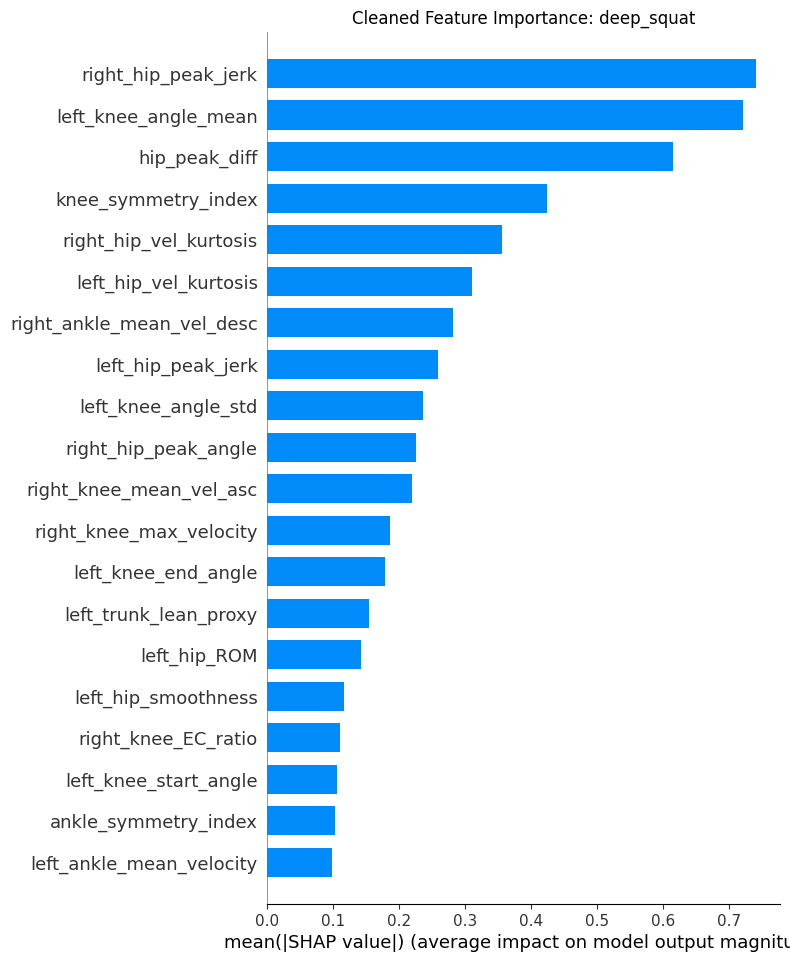

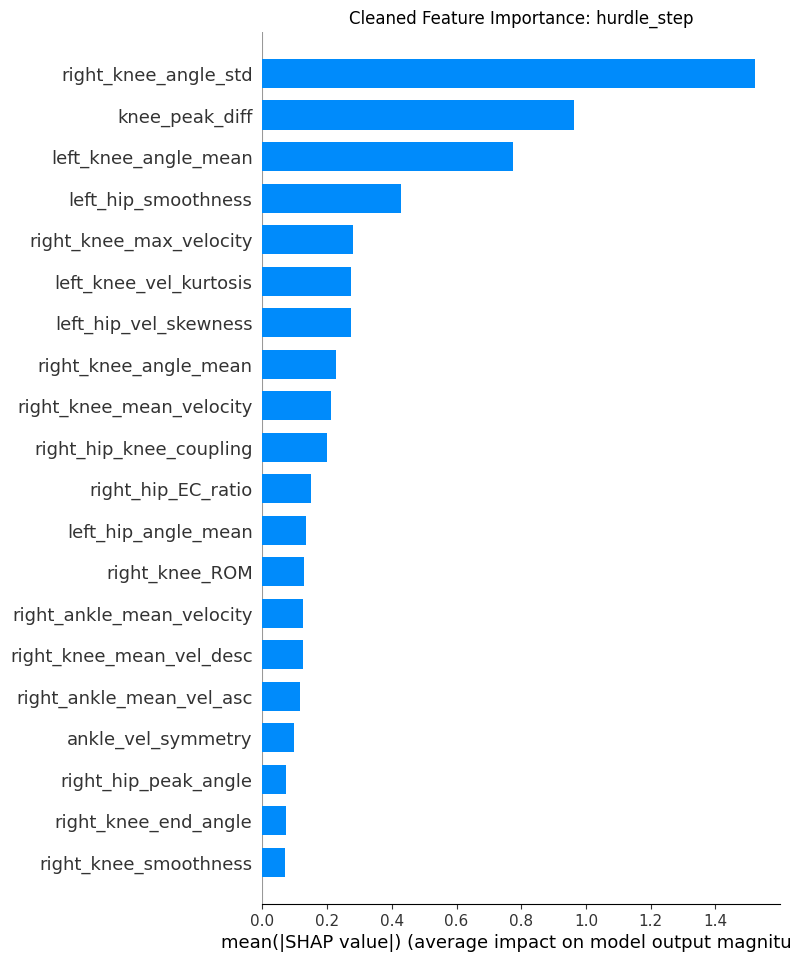

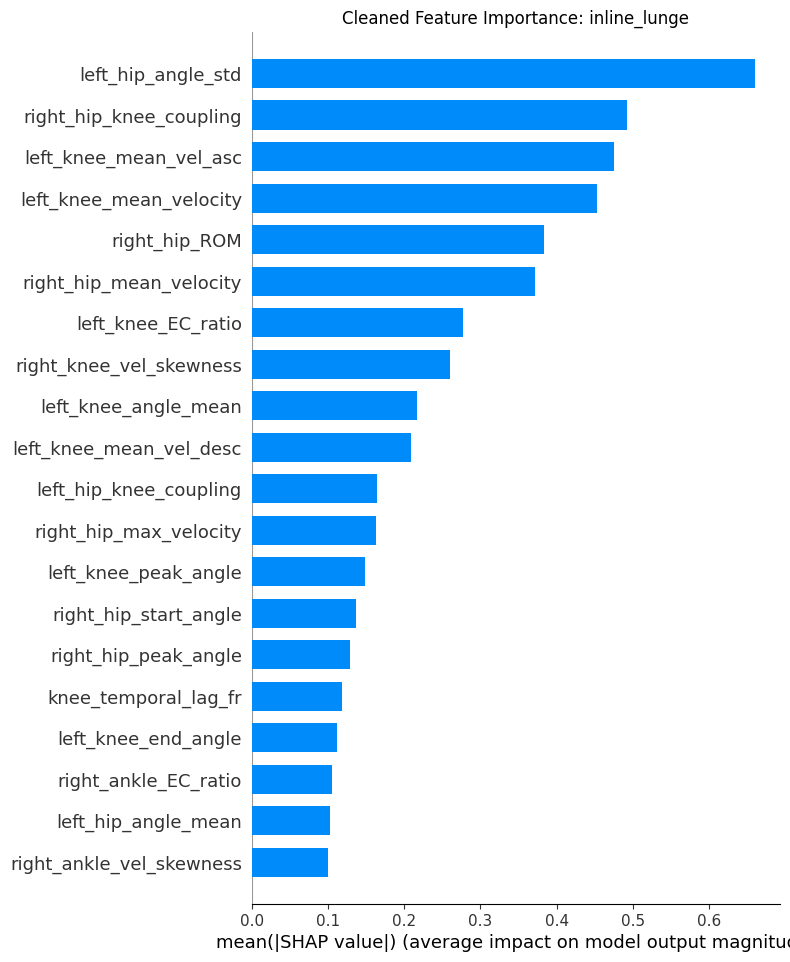

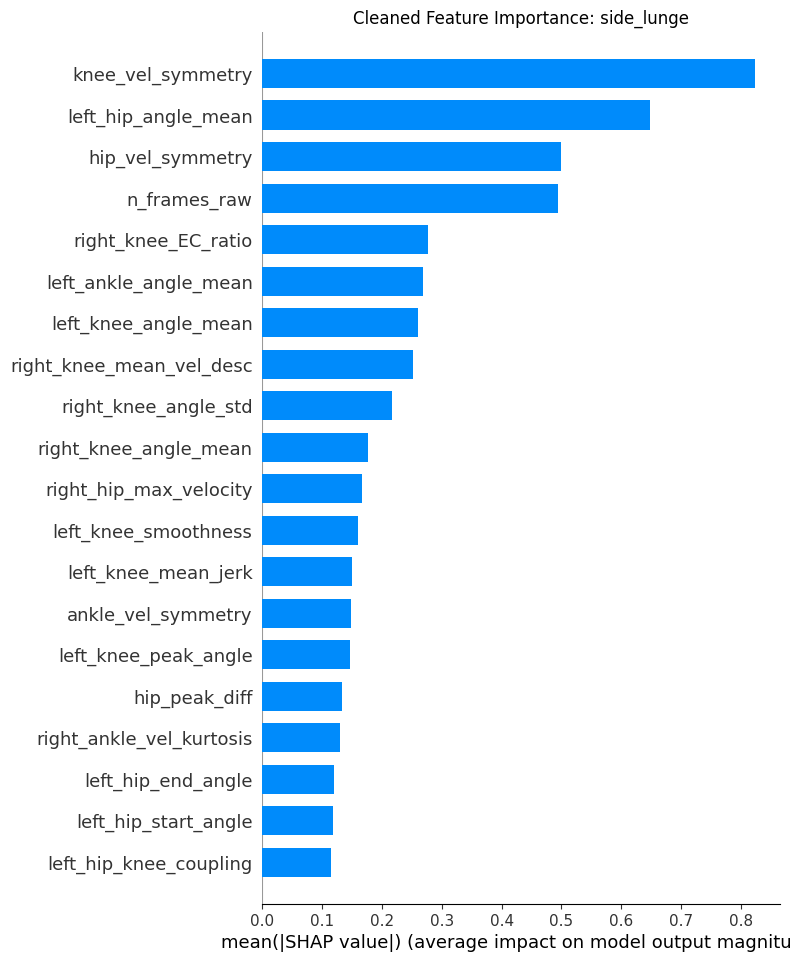

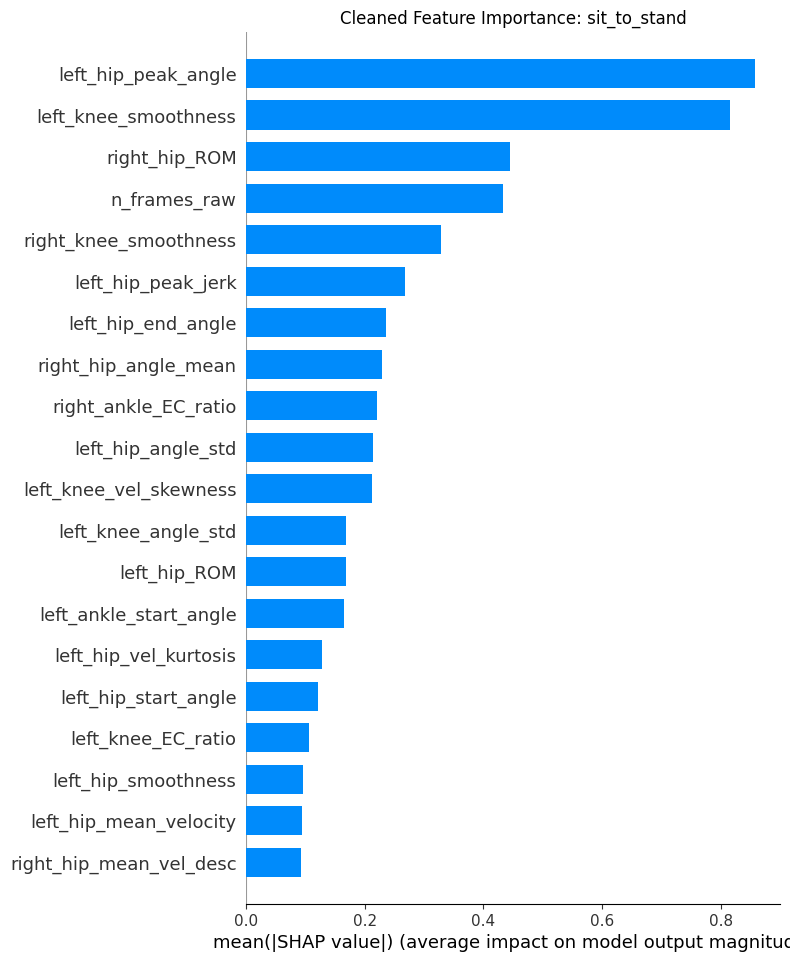

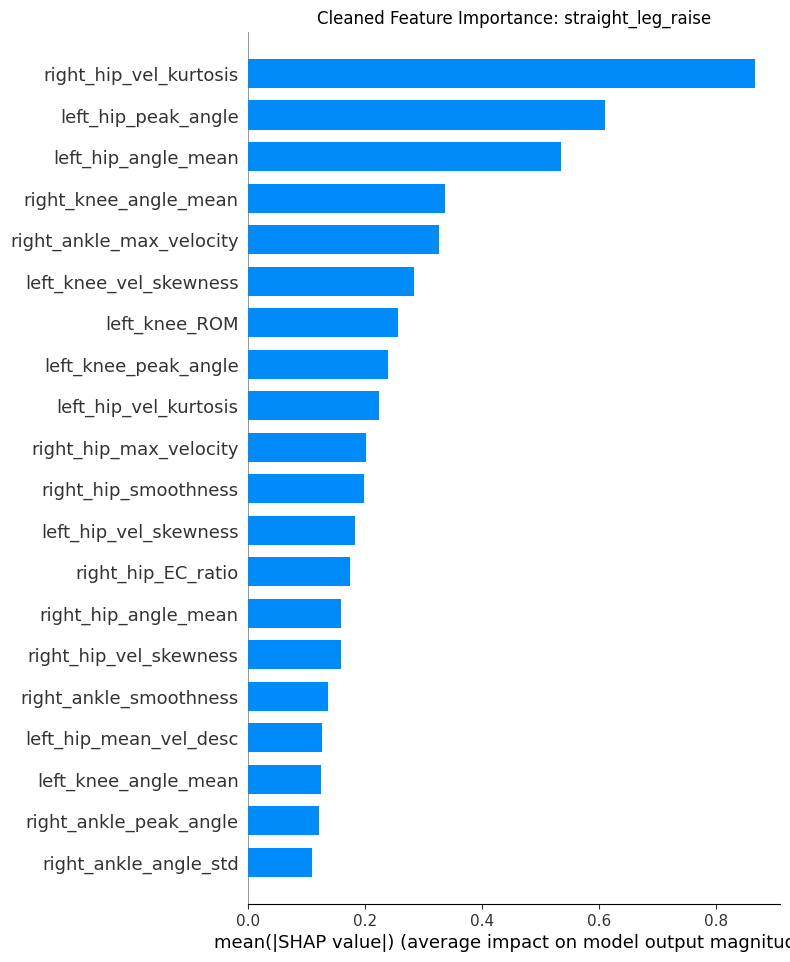

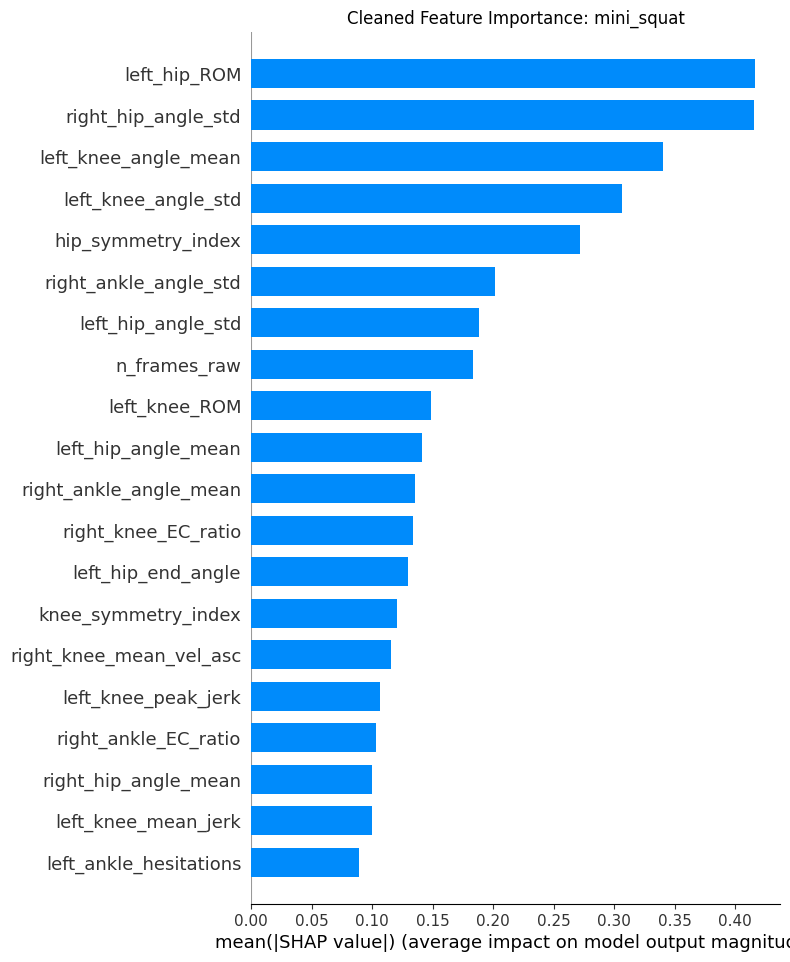

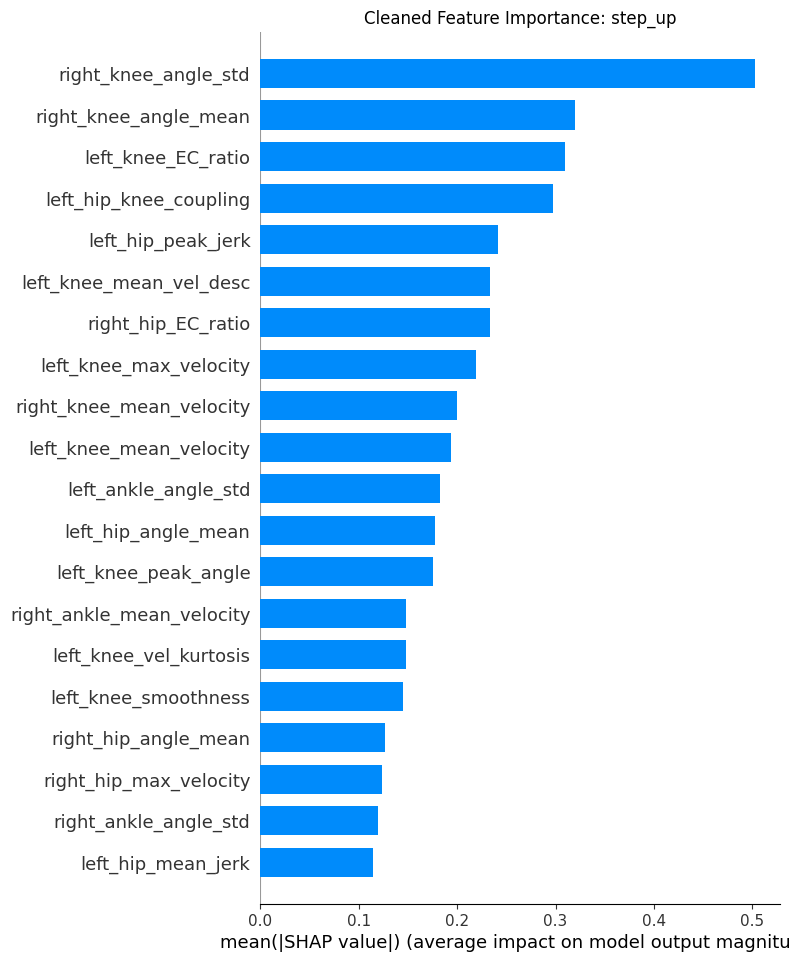

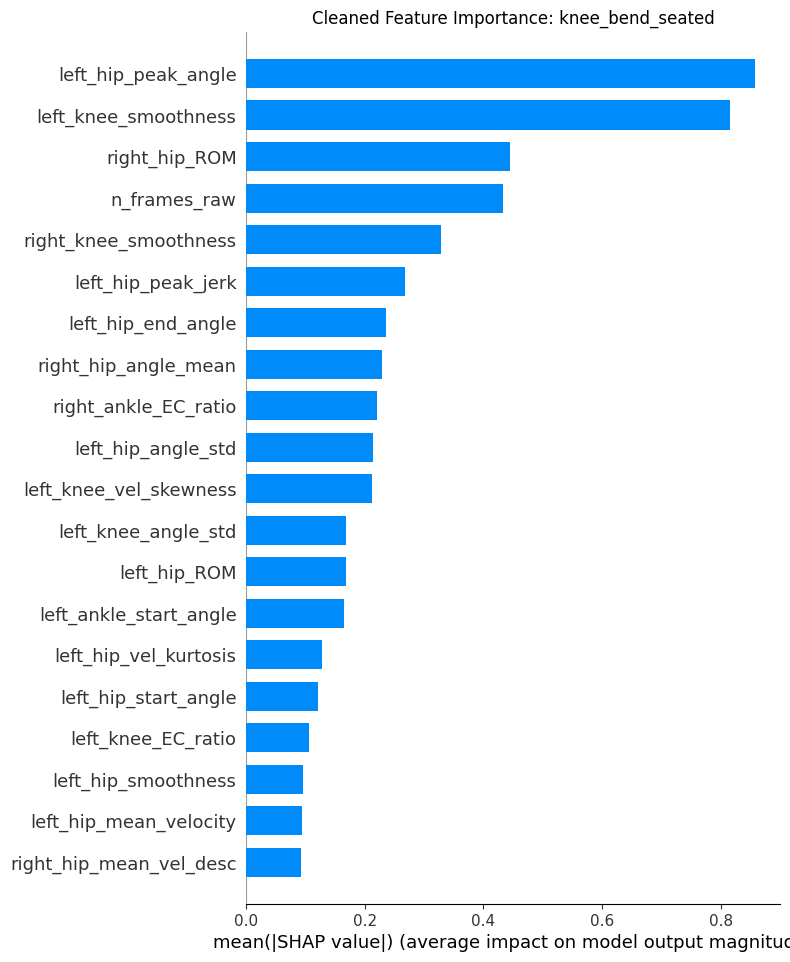

In [8]:
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

df = pd.read_csv("combined_exercises_master.csv")

unique_exercises = df['exercise'].unique()

for ex in unique_exercises:
    ex_df = df[df['exercise'] == ex]

    # Exclude 'valgus', 'clinical_flags' and metadata from features
    features = [col for col in ex_df.columns if col not in ['rep_id', 'exercise', 'target_label', 'subject_id', 'clinical_flags'] and 'valgus' not in col.lower()]

    X = ex_df[features]
    y = ex_df['target_label']

    model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5)
    model.fit(X, y)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    plt.figure()
    shap.summary_plot(shap_values, X, plot_type="bar", show=False)
    plt.title(f"Cleaned Feature Importance: {ex}")
    plt.show()